Passo 1: Bloco de importação de bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import random
import os
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

RF01: Geração e salvamento do dataset sintético com 300 registros de clientes. Obs: Aqui foram adicionados dados intencionalmente sujos para posterior limpeza:

In [2]:
def gerar_dataset_ecommerce(n_registros=300, seed=42):
    """Gera um dataset sintético de e-commerce brasileiro com dados
    propositalmente sujos: valores nulos, datas inválidas e strings
    com espaços extras — para praticar limpeza no RF03."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = [
        'Tênis Esportivo', 'Smartphone Samsung', 'Notebook Dell',
        'Fone Bluetooth', 'Camiseta Algodão', 'Calça Jeans',
        'Mochila Escolar', 'Relógio Digital', 'Perfume Importado',
        'Cafeteira Elétrica'
    ]
    categorias = {
        'Tênis Esportivo':    'Calçados',
        'Smartphone Samsung': 'Eletrônicos',
        'Notebook Dell':      'Eletrônicos',
        'Fone Bluetooth':     'Eletrônicos',
        'Camiseta Algodão':   'Vestuário',
        'Calça Jeans':        'Vestuário',
        'Mochila Escolar':    'Acessórios',
        'Relógio Digital':    'Acessórios',
        'Perfume Importado':  'Beleza',
        'Cafeteira Elétrica': 'Eletrodomésticos'
    }
    precos = {
        'Tênis Esportivo':    320,
        'Smartphone Samsung': 1850,
        'Notebook Dell':      3200,
        'Fone Bluetooth':     210,
        'Camiseta Algodão':   79,
        'Calça Jeans':        149,
        'Mochila Escolar':    130,
        'Relógio Digital':    280,
        'Perfume Importado':  390,
        'Cafeteira Elétrica': 250
    }
    regioes = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']
    estados = {
        'Sudeste':      ['SP', 'RJ', 'MG', 'ES'],
        'Sul':          ['PR', 'SC', 'RS'],
        'Nordeste':     ['BA', 'PE', 'CE', 'MA', 'RN'],
        'Centro-Oeste': ['GO', 'MT', 'MS', 'DF'],
        'Norte':        ['AM', 'PA', 'RO', 'AC']
    }
    pagamentos = ['Cartão de Crédito', 'Boleto', 'Pix', 'Cartão de Débito']
    clientes = [f"Cliente_{i:03d}" for i in range(1, 51)]
    data_inicio = datetime(2024, 1, 1)

    dados = []
    for i in range(n_registros):
        produto  = random.choice(produtos)
        regiao   = random.choice(regioes)
        estado   = random.choice(estados[regiao])
        qtd      = random.randint(1, 5)
        preco    = precos[produto]
        data     = data_inicio + timedelta(days=random.randint(0, 364))
        cliente  = random.choice(clientes)
        pagamento = random.choice(pagamentos)

        # Dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            qtd = None                      # valor nulo
        if random.random() < 0.04:
            preco = None                    # valor nulo
        if random.random() < 0.03:
            produto = "  " + produto        # espaço extra (string suja)
        if random.random() < 0.03:
            cliente = cliente + "  "        # espaço extra no final
        if random.random() < 0.02:
            pagamento = None                # pagamento nulo

        data_str = (data.strftime("%Y-%m-%d")
                    if random.random() > 0.02 else "DATA INVALIDA")

        dados.append({
            "id_pedido":        i + 1,
            "data_pedido":      data_str,
            "cliente":          cliente,
            "produto":          produto,
            "categoria":        categorias.get(produto.strip(), "Outros"),
            "regiao":           regiao,
            "estado":           estado,
            "quantidade":       qtd,
            "preco_unitario":   preco,
            "forma_pagamento":  pagamento,
        })

    return pd.DataFrame(dados)


# Gerar e salvar
df_bruto = gerar_dataset_ecommerce()
os.makedirs("../data/raw", exist_ok=True)
df_bruto.to_csv("../data/raw/vendas.csv", index=False)

print(f"Dataset gerado com {len(df_bruto)} registros e {len(df_bruto.columns)} colunas.")
print(f"Colunas: {list(df_bruto.columns)}")
df_bruto.head()

Dataset gerado com 300 registros e 10 colunas.
Colunas: ['id_pedido', 'data_pedido', 'cliente', 'produto', 'categoria', 'regiao', 'estado', 'quantidade', 'preco_unitario', 'forma_pagamento']


,id_pedido,data_pedido,cliente,produto,categoria,regiao,estado,quantidade,preco_unitario,forma_pagamento
0,1,2024-04-24,Cliente_009,Smartphone Samsung,Eletrônicos,Sudeste,MG,2.0,1850.0,Cartão de Crédito
1,2,2024-04-11,Cliente_046,Perfume Importado,Beleza,Norte,AM,5.0,390.0,Cartão de Débito
2,3,2024-06-21,Cliente_007,Calça Jeans,Vestuário,Nordeste,PE,2.0,149.0,Cartão de Crédito
3,4,2024-05-30,Cliente_041,Smartphone Samsung,Eletrônicos,Centro-Oeste,GO,5.0,1850.0,Pix
4,5,2024-08-20,Cliente_041,Fone Bluetooth,Eletrônicos,Sudeste,ES,3.0,210.0,Pix


RF02: Inspecionando os dados onde ocorre a inspeção do dataset carregado e exibe as informações básicas.


In [3]:
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame:
    shape, colunas, tipos, nulos e estatísticas descritivas."""
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print(f"\nEstatísticas descritivas:\n{df.describe()}")
    return df.describe(include="all")


inspecionar_dados(df_bruto)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (300, 10)

Colunas: ['id_pedido', 'data_pedido', 'cliente', 'produto', 'categoria', 'regiao', 'estado', 'quantidade', 'preco_unitario', 'forma_pagamento']

Tipos de dados:
id_pedido            int64
data_pedido            str
cliente                str
produto                str
categoria              str
regiao                 str
estado                 str
quantidade         float64
preco_unitario     float64
forma_pagamento        str
dtype: object

Valores nulos por coluna:
id_pedido           0
data_pedido         0
cliente             0
produto             0
categoria           0
regiao              0
estado              0
quantidade          8
preco_unitario      8
forma_pagamento    10
dtype: int64

Primeiros registros:
   id_pedido data_pedido        cliente             produto    categoria  \
0          1  2024-04-24    Cliente_009  Smartphone Samsung  Eletrônicos   
1          2  2024-04-11  Cliente_046     Perfume Importado       

,id_pedido,data_pedido,cliente,produto,categoria,regiao,estado,quantidade,preco_unitario,forma_pagamento
count,300.000000,300,300,300,300,300,300,292.000000,292.000000,290
unique,NaN,206,60,16,6,5,20,NaN,NaN,4
top,NaN,DATA INVALIDA,Cliente_007,Notebook Dell,Eletrônicos,Sul,PR,NaN,NaN,Pix
freq,NaN,6,12,40,95,68,29,NaN,NaN,82
mean,150.500000,NaN,NaN,NaN,NaN,NaN,NaN,2.904110,792.969178,NaN
std,86.746758,NaN,NaN,NaN,NaN,NaN,NaN,1.373929,1072.918377,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,79.000000,NaN
25%,75.750000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,149.000000,NaN
50%,150.500000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,280.000000,NaN
75%,225.250000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,390.000000,NaN


 RF03: Limpeza, tratamento dos dados e a  geração da v1. Aqui também são removidas as linhas com valores nulos, remoção de linhas com datas inválidas, conversão da coluna de data para o tipo datetime, remoção de espaços extras e posterior exposição de valores removidos.

In [4]:
def limpar_strings_regex(df, colunas):
    """Usa expressões regulares para normalizar colunas de texto:
    - Colapsa múltiplos espaços internos em um único espaço (re.sub)
    - Remove espaços nas pontas da string (.strip())
    - Preserva células nulas sem lançar erro (pd.notna)"""
    df = df.copy()
    for col in colunas:
        df[col] = df[col].apply(
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s
        )
    return df


def limpar_dados(df):
    """Limpa o DataFrame de e-commerce em quatro etapas:
    1. Normaliza strings com regex (espaços extras)
    2. Converte datas e remove registros com datas inválidas
    3. Remove linhas com valores nulos em colunas obrigatórias
    4. Garante os tipos numéricos corretos
    Retorna: (df_limpo, relatorio)"""
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}

    # Etapa 1: limpeza de strings com regex
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # Etapa 2: conversão de datas
    df["data_pedido"] = pd.to_datetime(df["data_pedido"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_pedido"].isnull().sum())
    df = df.dropna(subset=["data_pedido"])

    # Etapa 3: remoção de nulos em colunas obrigatórias
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # Etapa 4: garantia de tipos numéricos
    df["quantidade"]     = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    relatorio["registros_iniciais"]        = n_inicial
    relatorio["registros_finais"]          = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df)

    print("=== RELATÓRIO DE LIMPEZA ===")
    for k, v in relatorio.items():
        print(f"  {k}: {v}")

    return df, relatorio


# Executar limpeza e salvar como v1 (outliers mantidos)
df_v1, relatorio = limpar_dados(df_bruto)
os.makedirs("../data/processed/v1_com_outliers", exist_ok=True)
df_v1.to_csv("../data/processed/v1_com_outliers/vendas_v1.csv", index=False)

print("\nv1 salva em data/processed/v1_com_outliers/")
df_v1.head()

=== RELATÓRIO DE LIMPEZA ===
  datas_invalidas_removidas: 6
  linhas_nulas_removidas: 16
  registros_iniciais: 300
  registros_finais: 278
  registros_removidos_total: 22

v1 salva em data/processed/v1_com_outliers/


C:\Users\lgert\AppData\Local\Temp\ipykernel_20204\3453612851.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


,id_pedido,data_pedido,cliente,produto,categoria,regiao,estado,quantidade,preco_unitario,forma_pagamento
0,1,2024-04-24,Cliente_009,Smartphone Samsung,Eletrônicos,Sudeste,MG,2,1850.0,Cartão de Crédito
1,2,2024-04-11,Cliente_046,Perfume Importado,Beleza,Norte,AM,5,390.0,Cartão de Débito
2,3,2024-06-21,Cliente_007,Calça Jeans,Vestuário,Nordeste,PE,2,149.0,Cartão de Crédito
3,4,2024-05-30,Cliente_041,Smartphone Samsung,Eletrônicos,Centro-Oeste,GO,5,1850.0,Pix
4,5,2024-08-20,Cliente_041,Fone Bluetooth,Eletrônicos,Sudeste,ES,3,210.0,Pix


RF04: Detectar outliers e gerar a v2:

In [5]:
def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    """Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).
    Parâmetros:
        colunas : lista de colunas numéricas a verificar
        fator   : multiplicador do IQR para definir os limites (padrão=1.5)
        metodo  : 'remover' exclui as linhas com outliers;
                  'limitar' aplica winsorização (substitui pelo limite)
    Retorna o DataFrame tratado sem modificar o original (usa .copy())."""
    df = df.copy()

    for col in colunas:
        q1      = df[col].quantile(0.25)
        q3      = df[col].quantile(0.75)
        iqr     = q3 - q1
        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr

        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f"  {col}: {n_out} outliers detectados "
              f"(lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})")

        if metodo == 'remover':
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    return df


# Cópia temporária para detectar outliers de receita antes do RF05
df_v1_tmp = df_v1.copy()
df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]

df_v2 = tratar_outliers(
    df_v1_tmp,
    colunas=["quantidade", "receita_total"],
    metodo='remover'
)

# Remove coluna temporária — será recriada definitivamente no RF05
df_v2 = df_v2.drop(columns=["receita_total"])

print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")

os.makedirs("../data/processed/v2_outliers_tratado", exist_ok=True)
df_v2.to_csv("../data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)

print("\nv2 salva em data/processed/v2_outliers_tratado/")
df_v2.head()

  quantidade: 0 outliers detectados (lim_inf=-1.00, lim_sup=7.00)
  receita_total: 46 outliers detectados (lim_inf=-1975.00, lim_sup=4145.00)

v1 = 278 linhas (com outliers)
v2 = 232 linhas (outliers removidos)
Diferença = 46 linhas removidas

v2 salva em data/processed/v2_outliers_tratado/


,id_pedido,data_pedido,cliente,produto,categoria,regiao,estado,quantidade,preco_unitario,forma_pagamento
0,1,2024-04-24,Cliente_009,Smartphone Samsung,Eletrônicos,Sudeste,MG,2,1850.0,Cartão de Crédito
1,2,2024-04-11,Cliente_046,Perfume Importado,Beleza,Norte,AM,5,390.0,Cartão de Débito
2,3,2024-06-21,Cliente_007,Calça Jeans,Vestuário,Nordeste,PE,2,149.0,Cartão de Crédito
4,5,2024-08-20,Cliente_041,Fone Bluetooth,Eletrônicos,Sudeste,ES,3,210.0,Pix
6,7,2024-05-17,Cliente_005,Fone Bluetooth,Eletrônicos,Sudeste,MG,4,210.0,Boleto


 RF05: Colunas derivadas:

In [6]:
def criar_colunas_derivadas(df):
    """Cria colunas calculadas a partir do dataset limpo:
    - receita_total      : quantidade × preco_unitario
    - mes / trimestre / ano : componentes extraídos da data
    - faixa_receita_item : classificação do valor de cada pedido (np.select)"""
    df = df.copy()

    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    df["mes"]       = df["data_pedido"].dt.month
    df["trimestre"] = df["data_pedido"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"]       = df["data_pedido"].dt.year

    condicoes = [
        df["receita_total"] < 300,
        (df["receita_total"] >= 300) & (df["receita_total"] < 2000),
        df["receita_total"] >= 2000,
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("COLUNAS DERIVADAS CRIADAS")
    print(df[["data_pedido", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())
    return df


df = criar_colunas_derivadas(df_v2)
df[["data_pedido", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head()

COLUNAS DERIVADAS CRIADAS
  data_pedido  receita_total  mes trimestre faixa_receita_item
0  2024-04-24         3700.0    4        Q2         Alto Valor
1  2024-04-11         1950.0    4        Q2        Médio Valor
2  2024-06-21          298.0    6        Q2        Baixo Valor
4  2024-08-20          630.0    8        Q3        Médio Valor
6  2024-05-17          840.0    5        Q2        Médio Valor


,data_pedido,receita_total,mes,trimestre,faixa_receita_item
0,2024-04-24,3700.0,4,Q2,Alto Valor
1,2024-04-11,1950.0,4,Q2,Médio Valor
2,2024-06-21,298.0,6,Q2,Baixo Valor
4,2024-08-20,630.0,8,Q3,Médio Valor
6,2024-05-17,840.0,5,Q2,Médio Valor


RF06: Métricas agregadas usando o groupby:

In [7]:
def calcular_metricas(df):
    """Calcula métricas agregadas por mês, produto, categoria,
    região e estado — usando groupby + agg com nomeação explícita."""
    metricas = {}

    # Receita e volume por mês
    metricas["por_mes"] = (
        df.groupby("mes")
        .agg(
            receita_total=("receita_total", "sum"),
            quantidade=("quantidade",    "sum"),
            n_pedidos=("id_pedido",      "count"),
        )
        .reset_index()
        .sort_values("mes")
    )

    # Top 5 produtos por receita
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    # Receita por categoria
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    # Receita e ticket médio por região
    metricas["por_regiao"] = (
        df.groupby("regiao")
        .agg(
            receita_total=("receita_total", "sum"),
            media_ticket=("receita_total",  "mean"),
        )
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    # Receita por estado (extra — aproveita coluna nova do e-commerce)
    metricas["por_estado"] = (
        df.groupby("estado")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))

    return metricas


metricas = calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_pedidos
   1        15010.0          45         16
   2        16192.0          56         20
   3        12396.0          16         10
   4        25268.0          74         23
   5        23620.0          70         25
   6        13627.0          50         18
   7        14896.0          47         18
   8        15562.0          49         21
   9        11338.0          48         16
  10        11907.0          35         16
  11        22327.0          72         26
  12        14390.0          71         23

=== TOP PRODUTOS ===
           produto  receita_total
     Notebook Dell        35200.0
 Perfume Importado        28860.0
Smartphone Samsung        25900.0
   Tênis Esportivo        24000.0
Cafeteira Elétrica        20750.0

=== POR CATEGORIA ===
       categoria  receita_total
     Eletrônicos        74960.0
      Acessórios        29240.0
          Beleza        28860.0
        Calçados        24000.0
Eletrodoméstico

RF07: Segmentação de clientes

In [ ]:
def segmentar_clientes(df):
    """Agrupa por cliente, calcula total gasto e classifica em:
        < R$ 3.000          → Bronze
        R$ 3.000–R$ 10.000  → Prata
        > R$ 10.000         → Ouro
    Usando a função lambda com ternário aninhado (if/elif/else em uma linha)."""
    clientes_df = (
        df.groupby("cliente")["receita_total"]
        .sum()
        .reset_index()
    )
    clientes_df.columns = ["cliente", "total_gasto"]

    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 10000 else ("Prata" if g >= 3000 else "Bronze")
    )

    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)

    print("=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    print(clientes_df.head(10).to_string(index=False))
    print(f"\nDistribuição de segmentos:\n{clientes_df['segmento'].value_counts()}")

    return clientes_df


clientes = segmentar_clientes(df)
clientes.head()

=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
    cliente  total_gasto segmento
Cliente_011      10095.0     Ouro
Cliente_048       9257.0    Prata
Cliente_046       8958.0    Prata
Cliente_020       8487.0    Prata
Cliente_005       7497.0    Prata
Cliente_007       7133.0    Prata
Cliente_041       7008.0    Prata
Cliente_013       6980.0    Prata
Cliente_016       6977.0    Prata
Cliente_019       6680.0    Prata

Distribuição de segmentos:
segmento
Prata     27
Bronze    20
Ouro       1
Name: count, dtype: int64


,cliente,total_gasto,segmento
10,Cliente_011,10095.0,Ouro
45,Cliente_048,9257.0,Prata
43,Cliente_046,8958.0,Prata
18,Cliente_020,8487.0,Prata
4,Cliente_005,7497.0,Prata


 RF08: Estatísticas com NumPy

In [9]:
def calcular_estatisticas_numpy(df):
    """Calcula estatísticas de receita usando NumPy diretamente.
    Demonstra:
    1. Operações vetorizadas (mean, median, std, sum, percentile)
    2. Broadcasting (divisão de array por escalar)
    3. Boolean indexing (máscara True/False sobre array)"""
    receitas = df["receita_total"].to_numpy()

    stats = {
        "media":         float(np.mean(receitas)),
        "mediana":       float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total":         float(np.sum(receitas)),
        "p25":           float(np.percentile(receitas, 25)),
        "p75":           float(np.percentile(receitas, 75)),
    }

    # Broadcasting: % de participação de cada pedido no total
    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"  Participação dos 5 maiores pedidos no total: "
          f"{np.sort(receitas_pct)[-5:].round(2)}%")

    # Boolean indexing: pedidos acima da média
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    print("\n=== ESTATÍSTICAS COM NUMPY ===")
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {k}: {v} pedidos")
        else:
            print(f"  {k}: R$ {v:.2f}")

    return stats


stats = calcular_estatisticas_numpy(df)

  Participação dos 5 maiores pedidos no total: [1.63 1.88 1.88 1.88 1.88]%

=== ESTATÍSTICAS COM NUMPY ===
  media: R$ 847.12
  mediana: R$ 613.00
  desvio_padrao: R$ 810.14
  total: R$ 196533.00
  p25: R$ 298.00
  p75: R$ 1120.00
  acima_da_media: 70 pedidos


 RF09: Gráficos

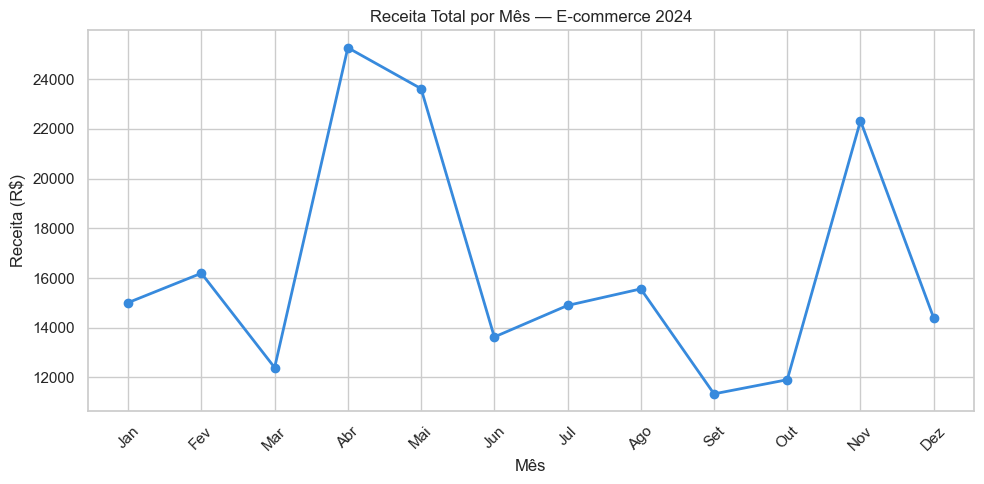

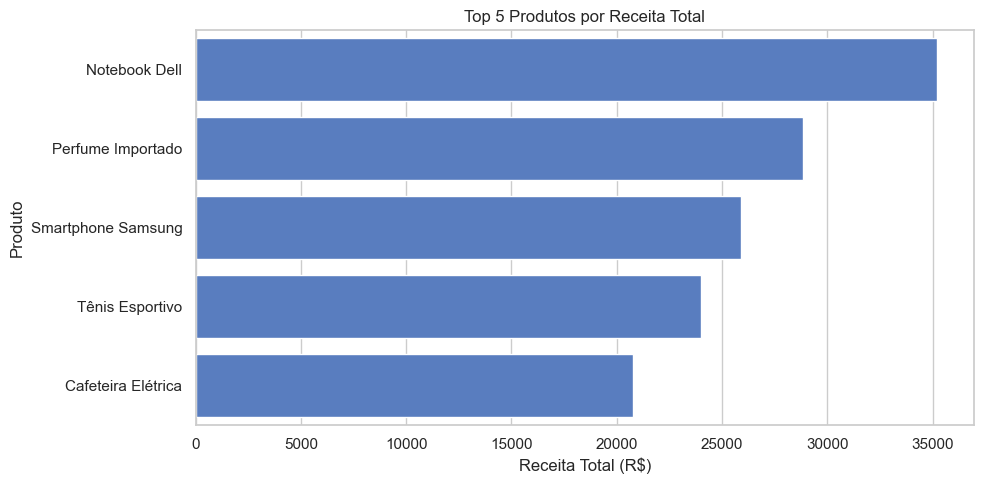

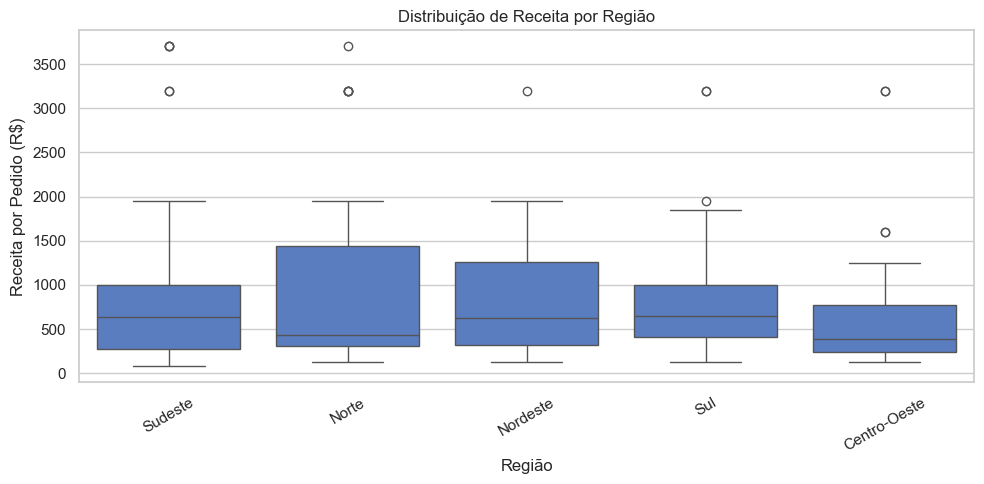

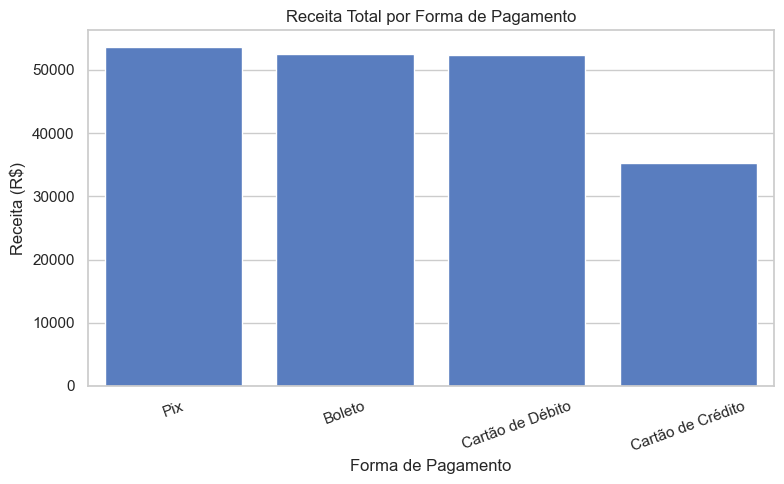

4 gráficos salvos em: ../outputs/graficos


In [10]:
def gerar_visualizacoes(df, metricas, output_dir="../outputs/graficos"):
    """Gera e exporta 4 gráficos informativos em PNG:
    1. Linha  — receita total por mês
    2. Barras — top 5 produtos por receita
    3. Boxplot — distribuição de receita por região
    4. Barras — receita por forma de pagamento"""
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")

    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun",
                   "Jul","Ago","Set","Out","Nov","Dez"]

    # Gráfico 1: Linha — Receita por Mês
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2, color="#378ADD")
    ax.set_title("Receita Total por Mês — E-commerce 2024")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 2: Barras horizontais — Top 5 Produtos
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax)
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 3: Boxplot — Distribuição de Receita por Região
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Pedido (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/dist_regiao.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 4: Barras — Receita por Forma de Pagamento
    fig, ax = plt.subplots(figsize=(8, 5))
    pag = (df.groupby("forma_pagamento")["receita_total"]
             .sum()
             .sort_values(ascending=False)
             .reset_index())
    sns.barplot(data=pag, x="forma_pagamento", y="receita_total", ax=ax)
    ax.set_title("Receita Total por Forma de Pagamento")
    ax.set_xlabel("Forma de Pagamento")
    ax.set_ylabel("Receita (R$)")
    plt.xticks(rotation=20)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_pagamento.png", dpi=120)
    plt.show()
    plt.close()

    print(f"4 gráficos salvos em: {output_dir}")


gerar_visualizacoes(df, metricas)

 RF10: Criação de funções de ordem superior:

In [11]:
def aplicar_transformacao(df, coluna, funcao):
    """Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma coluna '_transformado'.
    Parâmetros:
        df     : DataFrame de entrada
        coluna : nome da coluna a transformar
        funcao : função (ou lambda) a aplicar — o callback
    Retorna cópia do DataFrame com a nova coluna; não modifica o original."""
    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df


# Uso 1: classificar pedidos por ticket com lambda
df_demo = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: "Premium" if x > 2000 else ("Médio" if x >= 500 else "Baixo")
)
print("=== EXEMPLO 1: classificação por ticket ===")
print(df_demo[["receita_total", "receita_total_transformado"]].head(8))

# Uso 2: receita em milhares (R$ k)
df_demo2 = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: round(x / 1000, 2)
)
print("\n=== EXEMPLO 2: receita em milhares (R$ k) ===")
print(df_demo2[["receita_total", "receita_total_transformado"]].head(8))

=== EXEMPLO 1: classificação por ticket ===
   receita_total receita_total_transformado
0         3700.0                    Premium
1         1950.0                      Médio
2          298.0                      Baixo
4          630.0                      Médio
6          840.0                      Médio
7          560.0                      Médio
8          280.0                      Baixo
9         1950.0                      Médio

=== EXEMPLO 2: receita em milhares (R$ k) ===
   receita_total  receita_total_transformado
0         3700.0                        3.70
1         1950.0                        1.95
2          298.0                        0.30
4          630.0                        0.63
6          840.0                        0.84
7          560.0                        0.56
8          280.0                        0.28
9         1950.0                        1.95


 RF11: Exportar CSV e JSON

In [12]:
def exportar_resultados(metricas, clientes, stats):
    """Exporta os resultados da análise em dois formatos:
    - CSV : métricas mensais e segmentação de clientes
    - JSON: estatísticas gerais calculadas com NumPy
    Após exportar o JSON, lê de volta com json.load() para confirmar."""
    os.makedirs("../outputs", exist_ok=True)

    # Exportação CSV
    metricas["por_mes"].to_csv(
        "../outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/metricas_por_mes.csv")

    clientes.to_csv(
        "../outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/segmentacao_clientes.csv")

    # Exportação JSON
    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    caminho_json = "../outputs/estatisticas_gerais.json"

    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print(f"JSON exportado: {caminho_json}")

    # Leitura de volta para confirmar
    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)
    print("\nJSON lido de volta para confirmação:")
    print(json.dumps(lido, indent=2, ensure_ascii=False))


exportar_resultados(metricas, clientes, stats)

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: ../outputs/estatisticas_gerais.json

JSON lido de volta para confirmação:
{
  "media": 847.12,
  "mediana": 613.0,
  "desvio_padrao": 810.14,
  "total": 196533.0,
  "p25": 298.0,
  "p75": 1120.0,
  "acima_da_media": 70.0
}


RF12: Consolidação final

In [13]:
# RF12 — CONSOLIDAÇÃO FINAL
# Escolhemos df_v2 (outliers removidos) como base da análise final.
# A v1 está preservada em data/processed/ para consulta futura.

os.makedirs("../data/final", exist_ok=True)
df.to_csv("../data/final/vendas_final.csv", index=False)
print("Dataset final salvo em: data/final/vendas_final.csv")

# Verificar todos os arquivos gerados
print("\n=== ARQUIVOS GERADOS ===")
for pasta in [
    "../data/raw",
    "../data/processed/v1_com_outliers",
    "../data/processed/v2_outliers_tratado",
    "../data/final",
    "../outputs",
    "../outputs/graficos",
]:
    arquivos = os.listdir(pasta) if os.path.exists(pasta) else ["(pasta não encontrada)"]
    for arq in arquivos:
        print(f"  {pasta}/{arq}")

Dataset final salvo em: data/final/vendas_final.csv

=== ARQUIVOS GERADOS ===
  ../data/raw/vendas.csv
  ../data/processed/v1_com_outliers/vendas_v1.csv
  ../data/processed/v2_outliers_tratado/vendas_v2.csv
  ../data/final/vendas_final.csv
  ../outputs/estatisticas_gerais.json
  ../outputs/graficos
  ../outputs/metricas_por_mes.csv
  ../outputs/segmentacao_clientes.csv
  ../outputs/graficos/dist_regiao.png
  ../outputs/graficos/receita_por_mes.png
  ../outputs/graficos/receita_por_pagamento.png
  ../outputs/graficos/top_produtos.png
